In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import seaborn as sns
sns.set_style('whitegrid')

import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

from datetime import datetime
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)


In [2]:
df=pd.read_csv("diabetes.csv", encoding='latin1')

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

##### EDA #####

In [4]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [6]:
df.shape

(768, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

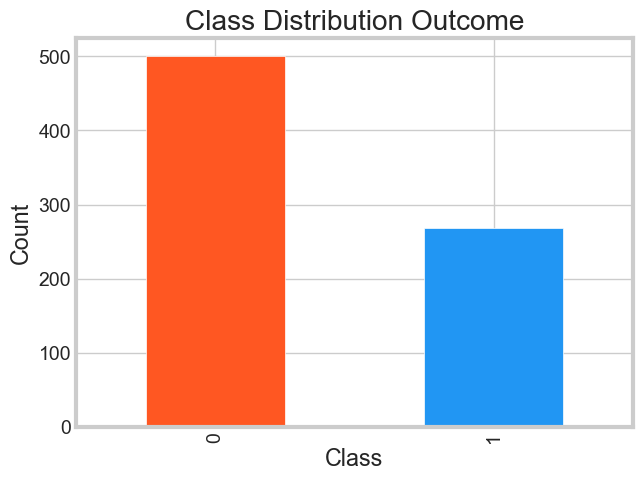

In [14]:
# توزيع الكلاسات بصرياً
df["Outcome"].value_counts().plot(kind="bar", color=["#FF5722", "#2196F3"])
plt.title("Class Distribution Outcome")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [15]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

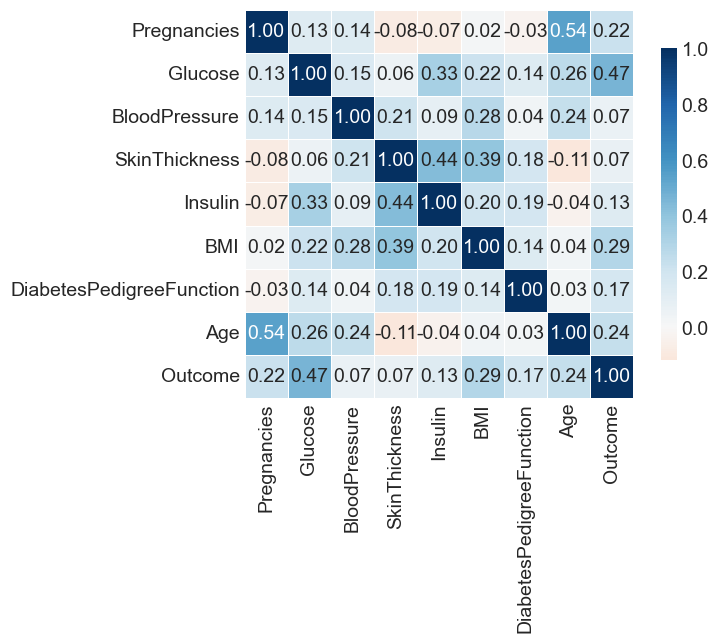

In [16]:
sns.heatmap(df.corr(),
            annot=True,        # عرض الأرقام داخل المربعات
            fmt='.2f',         # تنسيق الأرقام (منزلتين عشريتين)
            cmap='RdBu',       # ألوان (أحمر للارتباط الموجب، أزرق للسالب)
            center=0,          # جعل الصفر في المنتصف
            square=True,       # جعل المربعات مربعة الشكل
            linewidths=0.5,    # عرض الخطوط الفاصلة
            cbar_kws={"shrink": 0.8})  # حجم شريط الألوان

##### Data Cleaning #####

In [17]:

# دالة لاكتشاف القيم المتطرفة
def detect_outliers_iqr(data, column):
    """
    ترجع عدد القيم المتطرفة في عمود معين باستخدام IQR
    """
    Q1 = data[column].quantile(0.25)  # الربع الأول
    Q3 = data[column].quantile(0.75)  # الربع الثالث
    IQR = Q3 - Q1                      # المدى الربيعي
    
    # حدود القيم الطبيعية
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # تحديد القيم المتطرفة
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    print(f"عمود: {column}")
    print(f"  - الحد الأدنى: {lower_bound:.2f}")
    print(f"  - الحد الأقصى: {upper_bound:.2f}")
    print(f"  - عدد القيم المتطرفة: {len(outliers)}")
    print(f"  - نسبة القيم المتطرفة: {(len(outliers)/len(data))*100:.2f}%\n")
    
    return outliers

# تطبيق الدالة على كل الأعمدة الرقمية
numeric_columns = df.select_dtypes(include=[np.number]).columns

for col in numeric_columns:
    detect_outliers_iqr(df, col)

عمود: Pregnancies
  - الحد الأدنى: -6.50
  - الحد الأقصى: 13.50
  - عدد القيم المتطرفة: 4
  - نسبة القيم المتطرفة: 0.52%

عمود: Glucose
  - الحد الأدنى: 37.12
  - الحد الأقصى: 202.12
  - عدد القيم المتطرفة: 5
  - نسبة القيم المتطرفة: 0.65%

عمود: BloodPressure
  - الحد الأدنى: 35.00
  - الحد الأقصى: 107.00
  - عدد القيم المتطرفة: 45
  - نسبة القيم المتطرفة: 5.86%

عمود: SkinThickness
  - الحد الأدنى: -48.00
  - الحد الأقصى: 80.00
  - عدد القيم المتطرفة: 1
  - نسبة القيم المتطرفة: 0.13%

عمود: Insulin
  - الحد الأدنى: -190.88
  - الحد الأقصى: 318.12
  - عدد القيم المتطرفة: 34
  - نسبة القيم المتطرفة: 4.43%

عمود: BMI
  - الحد الأدنى: 13.35
  - الحد الأقصى: 50.55
  - عدد القيم المتطرفة: 19
  - نسبة القيم المتطرفة: 2.47%

عمود: DiabetesPedigreeFunction
  - الحد الأدنى: -0.33
  - الحد الأقصى: 1.20
  - عدد القيم المتطرفة: 29
  - نسبة القيم المتطرفة: 3.78%

عمود: Age
  - الحد الأدنى: -1.50
  - الحد الأقصى: 66.50
  - عدد القيم المتطرفة: 9
  - نسبة القيم المتطرفة: 1.17%

عمود: Outcome
  - الحد

In [18]:
# الخطوة 1 — نستبدل الـ zero values بـ NaN الأول
# (الأعمدة اللي فيها أصفار مستحيلة)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[zero_cols] = df[zero_cols].replace(0, np.nan)

print("Null values بعد استبدال الأصفار:")
print(df.isnull().sum())

Null values بعد استبدال الأصفار:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [19]:
# الخطوة 2 — نملا الـ NaN بالـ median
# بنستخدم median مش mean عشان الـ outliers مش بتأثر عليه
for col in zero_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("✅ تم معالجة الـ missing values")
print(df.isnull().sum())

✅ تم معالجة الـ missing values
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


C:\Users\tarek\AppData\Local\Temp\ipykernel_27532\2359547672.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\tarek\AppData\Local\Temp\ipykernel_27532\2359547672.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

#####  Feature Engineering  #####

In [21]:
# BMI بيتقسم لفئات طبية معروفة
df['BMI_Category'] = pd.cut(df['BMI'],
                             bins=[0, 18.5, 24.9, 29.9, 100],
                             labels=[0, 1, 2, 3])  # Underweight, Normal, Overweight, Obese
df['BMI_Category'] = df['BMI_Category'].astype(int)

print("BMI Categories:")
print(df['BMI_Category'].value_counts())

BMI Categories:
BMI_Category
3    483
2    179
1    102
0      4
Name: count, dtype: int64


In [22]:
# تقسيم العمر لفئات
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[0, 30, 45, 60, 100],
                          labels=[0, 1, 2, 3])  # Young, Middle, Senior, Elderly
df['Age_Group'] = df['Age_Group'].astype(int)

print("Age Groups:")
print(df['Age_Group'].value_counts())

Age Groups:
Age_Group
0    417
1    233
2     91
3     27
Name: count, dtype: int64


In [23]:
# مستوى السكر في الدم — مهم جداً لتشخيص السكري
df['Glucose_Level'] = pd.cut(df['Glucose'],
                              bins=[0, 99, 125, 200],
                              labels=[0, 1, 2])  # Normal, Pre-diabetic, Diabetic
df['Glucose_Level'] = df['Glucose_Level'].astype(int)

print("Glucose Levels:")
print(df['Glucose_Level'].value_counts())

Glucose Levels:
Glucose_Level
2    297
1    279
0    192
Name: count, dtype: int64


In [25]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Level
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,3,2,2
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,2,1,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,1,1,2
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,2,0,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,3,1,2


In [26]:
# نكتفي بالـ features الطبية بس
feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
new_features = ['BMI_Category', 'Age_Group', 'Glucose_Level']

all_features = feature_cols + new_features
print(f"✅ Total features: {len(all_features)}")  # 11

✅ Total features: 11


##### Preprocessing #####

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Features & Target
X = df[all_features].values
y = df['Outcome'].values

print("X shape:", X.shape)  # (768, 11)
print("y shape:", y.shape)  # (768,)

X shape: (768, 11)
y shape: (768,)


In [29]:
# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print("Train size:", X_train.shape[0])  
print("Test size:",  X_test.shape[0])   

Train size: 614
Test size: 154


In [30]:
# 3. Feature Scaling
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Mean after scaling:", X_train_sc.mean().round(4))   # ~0
print("STD after scaling:",  X_train_sc.std().round(4))    # ~1

Mean after scaling: 0.0
STD after scaling: 1.0


In [31]:
# 4. تأكد من الـ class balance
unique, counts = np.unique(y_train, return_counts=True)
print("\nClass Distribution in Train:")
for u, c in zip(unique, counts):
    print(f"  {'Diabetes' if u==1 else 'No Diabetes'}: {c} ({c/len(y_train)*100:.1f}%)")


Class Distribution in Train:
  No Diabetes: 400 (65.1%)
  Diabetes: 214 (34.9%)


#####  Feature Selection #####

In [32]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import VarianceThreshold

# أولاً — Variance Threshold
selector_var = VarianceThreshold(threshold=0.01)
X_train_var = selector_var.fit_transform(X_train_sc)
X_test_var  = selector_var.transform(X_test_sc)

print(f"Features قبل : {X_train_sc.shape[1]}")
print(f"Features بعد : {X_train_var.shape[1]}")

Features قبل : 11
Features بعد : 11


In [33]:
# ثانياً — SelectKBest
selector_kbest = SelectKBest(score_func=f_classif, k=8)
X_train_kbest = selector_kbest.fit_transform(X_train_sc, y_train)
X_test_kbest  = selector_kbest.transform(X_test_sc)

# أهمية كل feature
scores = pd.Series(selector_kbest.scores_, index=all_features)
print("\nFeature Scores:")
print(scores.sort_values(ascending=False).round(2))


Feature Scores:
Glucose                     217.76
Glucose_Level               152.23
BMI                          74.20
BMI_Category                 61.70
Insulin                      39.39
Age                          37.63
Age_Group                    35.56
SkinThickness                35.54
Pregnancies                  27.72
BloodPressure                21.29
DiabetesPedigreeFunction     17.19
dtype: float64


In [34]:
# ثالثاً — مقارنة النسختين
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

datasets = {
    "All Features (11)":  (X_train_sc,    X_test_sc),
    "Variance Filter":    (X_train_var,   X_test_var),
    "SelectKBest (8)":    (X_train_kbest, X_test_kbest),
}

print("📊 Feature Selection Comparison:")
print("-" * 45)
for name, (X_tr, _) in datasets.items():
    scores = cross_val_score(rf, X_tr, y_train, cv=cv, scoring="accuracy")
    print(f"  {name:<25} {scores.mean():.4f} ± {scores.std():.4f}")

📊 Feature Selection Comparison:
---------------------------------------------
  All Features (11)         0.7671 ± 0.0348
  Variance Filter           0.7671 ± 0.0348
  SelectKBest (8)           0.7442 ± 0.0404


In [35]:
# هنكمل بكل الـ features
X_train_final = X_train_sc
X_test_final  = X_test_sc

print(f"✅ Final Feature Count: {X_train_final.shape[1]}")  # 11

✅ Final Feature Count: 11


##### Modeling #####

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

# تعريف الموديلات
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":                  SVC(kernel="rbf", probability=True, random_state=42),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=42),
}

In [37]:
# Cross Validation — 5 Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

print("📊 Cross-Validation Results (5-Fold):")
print("-" * 45)

for name, model in models.items():
    scores = cross_val_score(model, X_train_final, y_train, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"  {name:<25} {scores.mean():.4f} ± {scores.std():.4f}")

📊 Cross-Validation Results (5-Fold):
---------------------------------------------
  Logistic Regression       0.7817 ± 0.0164
  Random Forest             0.7671 ± 0.0348
  SVM                       0.7800 ± 0.0352
  Gradient Boosting         0.7475 ± 0.0216


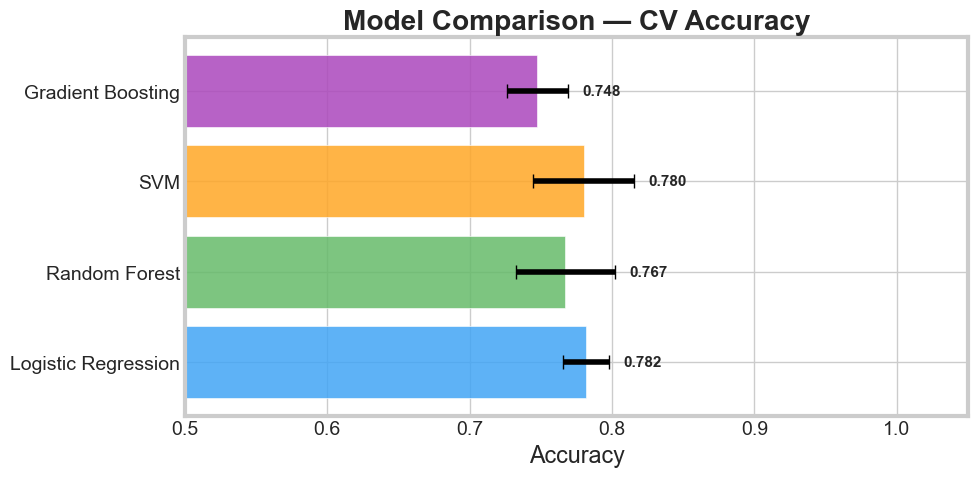

In [38]:
# بصرياً — مقارنة الموديلات
fig, ax = plt.subplots(figsize=(10, 5))

names  = list(results.keys())
means  = [results[n].mean() for n in names]
stds   = [results[n].std()  for n in names]
colors = ["#42A5F5", "#66BB6A", "#FFA726", "#AB47BC"]

ax.barh(names, means, xerr=stds, color=colors,
        alpha=0.85, edgecolor="white", capsize=5)

ax.set_title("Model Comparison — CV Accuracy", fontweight="bold")
ax.set_xlabel("Accuracy")
ax.set_xlim(0.5, 1.05)

for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(m + s + 0.01, i, f"{m:.3f}", va="center",
            fontweight="bold", fontsize=11)

plt.tight_layout()
plt.show()

###### Hyperparameter Tuning #######

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    "C":       [0.01, 0.1, 1, 10, 100],
    "solver":  ["lbfgs", "liblinear"],
    "penalty": ["l1", "l2"],
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_final, y_train)

print("✅ Best Params:", grid_lr.best_params_)
print("✅ Best Score:", round(grid_lr.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best Params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
✅ Best Score: 0.7915


C:\Users\tarek\.conda\envs\Elnemr\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
25 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\tarek\.conda\envs\Elnemr\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\tarek\.conda\envs\Elnemr\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\tarek\.conda\envs\Elnemr\Lib\site-packages\sklearn\linear_model\_logistic.

In [40]:
param_grid_rf = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "max_features":      ["sqrt", "log2"],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_final, y_train)

print("✅ Best Params:", grid_rf.best_params_)
print("✅ Best Score:", round(grid_rf.best_score_, 4))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
✅ Best Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
✅ Best Score: 0.785


In [41]:
param_grid_svm = {
    "C":      [0.1, 1, 10, 100],
    "gamma":  ["scale", "auto", 0.001, 0.01],
    "kernel": ["rbf", "poly"],
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_final, y_train)

print("✅ Best Params:", grid_svm.best_params_)
print("✅ Best Score:", round(grid_svm.best_score_, 4))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
✅ Best Params: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
✅ Best Score: 0.7866


In [42]:
param_grid_gb = {
    "n_estimators":  [100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth":     [3, 5, 7],
    "subsample":     [0.8, 1.0],
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train_final, y_train)

print("✅ Best Params:", grid_gb.best_params_)
print("✅ Best Score:", round(grid_gb.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
✅ Best Score: 0.7785


In [43]:
# هنكمل بـ Logistic Regression
best_model = grid_lr.best_estimator_
print("✅ Best Model:", best_model)

✅ Best Model: LogisticRegression(C=0.1, max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')


In [44]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_pred = best_model.predict(X_test_final)

# Accuracy
print("✅ Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

✅ Test Accuracy: 0.7078

📊 Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.76      0.81      0.78       100
    Diabetes       0.60      0.52      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



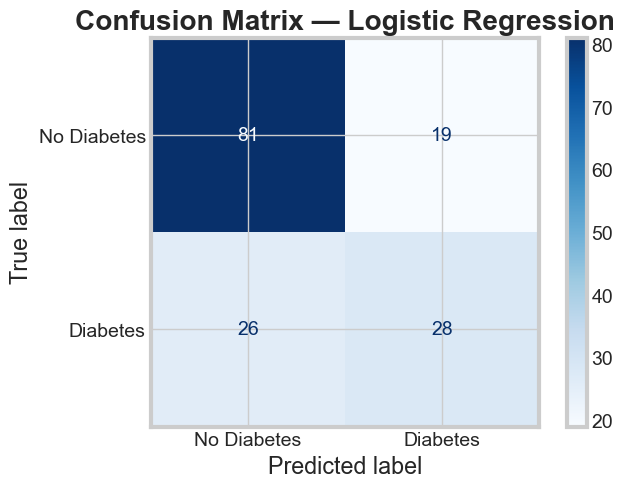

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No Diabetes", "Diabetes"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression", fontweight="bold")
plt.show()

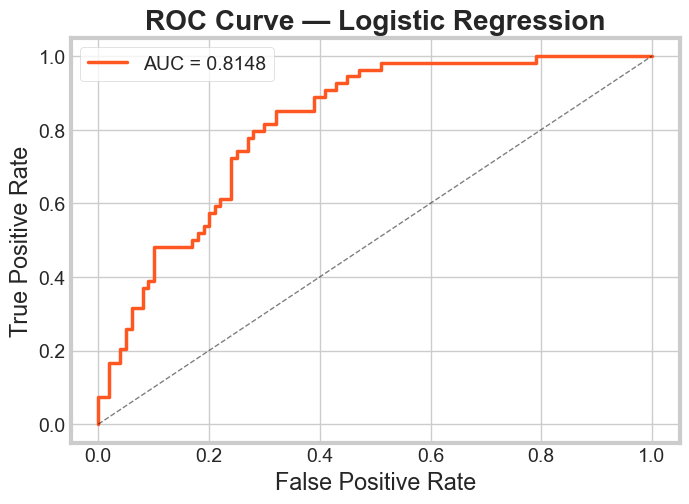

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test_final)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#FF5722", linewidth=2.5, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], "k--", linewidth=1, alpha=0.5)
plt.title("ROC Curve — Logistic Regression", fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [47]:
# بنقوله خد بالك من الـ Diabetes أكتر
best_model_balanced = LogisticRegression(
    C=0.1,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',  # ← ده الحل
    max_iter=1000,
    random_state=42
)

best_model_balanced.fit(X_train_final, y_train)
y_pred_balanced = best_model_balanced.predict(X_test_final)

print("✅ Test Accuracy:", round(accuracy_score(y_test, y_pred_balanced), 4))
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_balanced, target_names=["No Diabetes", "Diabetes"]))


✅ Test Accuracy: 0.7532

📊 Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.87      0.73      0.79       100
    Diabetes       0.61      0.80      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.76       154



In [48]:
# ده الموديل النهائي
best_model = best_model_balanced
print("✅ Final Model جاهز!")

✅ Final Model جاهز!


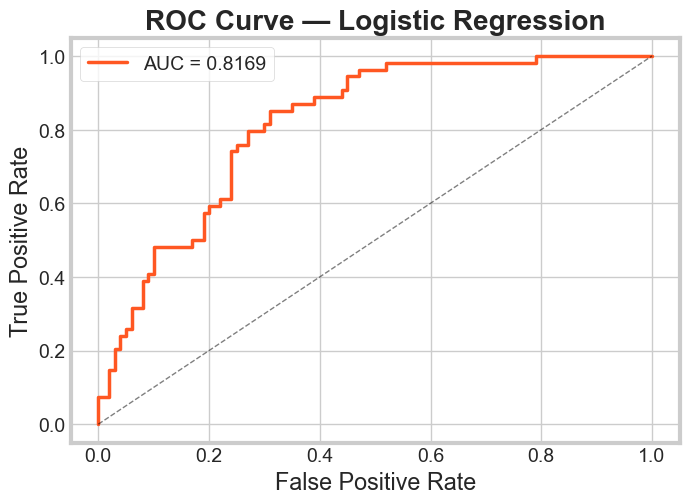

✅ AUC Score: 0.8169


In [49]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test_final)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#FF5722", linewidth=2.5, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], "k--", linewidth=1, alpha=0.5)
plt.title("ROC Curve — Logistic Regression", fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"✅ AUC Score: {auc:.4f}")

In [50]:
import joblib
import os

# عمل folder للموديل
os.makedirs("model", exist_ok=True)

# حفظ كل حاجة
joblib.dump(best_model, "model/logistic_regression.pkl")
joblib.dump(scaler,     "model/scaler.pkl")

print("✅ تم حفظ:")
print("   - model/logistic_regression.pkl")
print("   - model/scaler.pkl")

✅ تم حفظ:
   - model/logistic_regression.pkl
   - model/scaler.pkl


In [51]:
# تأكد إن الحفظ اشتغل
model_loaded  = joblib.load("model/logistic_regression.pkl")
scaler_loaded = joblib.load("model/scaler.pkl")

# تجربة prediction
sample        = X_test[0].reshape(1, -1)
sample_scaled = scaler_loaded.transform(sample)
prediction    = model_loaded.predict(sample_scaled)
probability   = model_loaded.predict_proba(sample_scaled)

print("✅ الموديل اتحمل صح!")
print(f"   النتيجة     : {'Diabetes 🩺' if prediction[0] == 1 else 'No Diabetes ✅'}")
print(f"   No Diabetes : {probability[0][0]:.2%}")
print(f"   Diabetes    : {probability[0][1]:.2%}")

✅ الموديل اتحمل صح!
   النتيجة     : Diabetes 🩺
   No Diabetes : 29.20%
   Diabetes    : 70.80%
